# 3-1 복잡한 분류 문제

본 노트북은 본문 3-1 절의 내용을 정리한다. 3-1 절은 다층 퍼셉트론의 등장 배경과 구조, 역전파 알고리즘의 개념을 다루며 실행 가능한 코드 예제([코드 N-M])는 포함하지 않는다.

따라서 이 노트북에는 본문에 대응하는 `# 코드 N-M` 셀이 없고, 절의 핵심 내용을 그림과 설명으로 보조하는 `# 참고 -` 셀로만 구성된다.

In [1]:
# 참고 - 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

## 라이브러리 import 와 시드 고정

In [2]:
# 참고 - 라이브러리 import 와 시드 고정
import random

import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## 3-1 의 핵심 내용 요약

- 퍼셉트론은 두 입력에 대해 항상 하나의 직선 결정 경계만 만들 수 있어, 직선 하나로 분류할 수 없는 **선형 분리 불가** 문제(예: XOR)를 풀지 못한다.
- 여러 직선 결정 경계를 계층적으로 조합하면 곡선 형태의 복잡한 결정 경계도 만들 수 있다. 이 아이디어를 일반화한 모델이 **다층 퍼셉트론(MLP)** 이다.
- 다층 퍼셉트론은 입력층 / 은닉층(하나 이상) / 출력층으로 구성되고, 인접한 두 층 사이는 완전 연결 계층(FC)으로 이어진다.
- 은닉층은 출력과 맞닿아 있지 않아 손실에서 직접 기울기를 계산할 수 없다. 출력층의 손실을 역방향으로 전파하면서 각 파라미터의 영향력을 분배해 기울기를 구하는 알고리즘이 **역전파 알고리즘** 이다.
- 역전파는 합성 함수의 미분 연쇄 법칙으로 한 번에 계산되며, 파이토치의 자동 미분이 이 과정을 자동으로 처리한다.

## 참고 시각화 — XOR 의 입력 분포

본문 [그림 3-1] 의 XOR 입력 분포(○: 0, ●: 1) 를 좌표 평면에 표시한다. **세 후보 직선 모두 ○ 와 ● 를 나누지 못한다** 는 사실을 직접 확인할 수 있다.

`viz.plot_decision_boundary` 의 `params=[(w1, w2, b), ...]` 형식으로 임의의 세 직선을 동시에 그렸다.

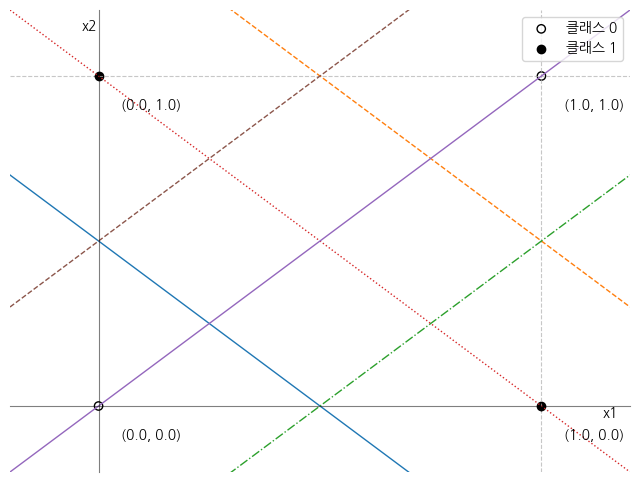

In [11]:
# 참고 - XOR 의 결과를 분류하는 결정 경계 후보 ([그림 3-1] 대응)
# XOR 의 입력/출력. 출력 0 -> ○, 출력 1 -> ●.
sample = (
    [0., 1., 0., 1.],   # x1
    [0., 0., 1., 1.],   # x2
    [0,  1,  1,  0 ],   # y (XOR)
)

# 세 후보 직선. 모두 0 과 1 을 분리하지 못한다.
# 직선 식 w1*x1 + w2*x2 + b = 0
viz.plot_decision_boundary(
    sample=sample,
    params=[(1., 1., -0.5), (1., 1., -1.5), (1., -1., -0.5),
             (1., 1., -1.), (1., -1., 0.), (1., -1., 0.5)],
    x_lim=(-0.2, 1.2), y_lim=(-0.2, 1.2),
    x_label='x1', y_label='x2',
)

어떤 직선을 그어도 ○(0) 두 점과 ●(1) 두 점을 분리할 수 없다. 직선 결정 경계를 만드는 단일 퍼셉트론만으로 XOR 분류 모델을 만들 수 없는 이유이다.

다음 절(3-2) 에서는 이 한계를 다층 퍼셉트론으로 직접 해결한다.